In [16]:
# Import libraries
import json
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from datetime import datetime
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import spacy
import os
import nltk
import ssl
import re
import logging
from functools import lru_cache
from nltk.sentiment import SentimentIntensityAnalyzer

# Create output directory and configure logging
output_dir = "competitor_content"
os.makedirs(output_dir, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(f"{output_dir}/analysis.log"),
        logging.StreamHandler()
    ]
)

# SSL Certificate fix
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download required NLTK data
nltk.download('vader_lexicon')

# Load spaCy NLP model
nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/michaelpreuss/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [17]:
# Define custom stop words
custom_stop_words = [
    "a", "about", "above", "across", "after", "again", "against", "all", "almost", "alone", "along",
    "already", "also", "although", "always", "among", "an", "and", "another", "any", "anybody", 
    "anyone", "anything", "anywhere", "are", "area", "areas", "around", "as", "ask", "asked", 
    "asking", "asks", "at", "away", "b", "back", "backed", "backing", "backs", "be", "became", 
    "because", "become", "becomes", "been", "before", "began", "behind", "being", "beings", 
    "best", "better", "between", "big", "both", "but", "by", "c", "came", "can", "cannot", 
    "case", "cases", "certain", "certainly", "clear", "clearly", "come", "could", "d", "did", 
    "differ", "different", "differently", "do", "does", "done", "down", "downed", "downing", 
    "downs", "during", "each", "early", "either", "end", "ended", "ending", "ends", "enough", 
    "even", "evenly", "ever", "every", "everybody", "everyone", "everything", "everywhere", 
    "face", "faces", "fact", "facts", "far", "felt", "few", "find", "finds", "first", "for", 
    "four", "from", "full", "fully", "further", "furthered", "furthering", "furthers", "gave", 
    "general", "generally", "get", "gets", "give", "given", "gives", "go", "going", "good", 
    "goods", "got", "great", "greater", "greatest", "group", "grouped", "grouping", "groups", 
    "had", "has", "have", "having", "he", "her", "here", "herself", "high", "higher", "highest", 
    "him", "himself", "his", "how", "however", "i", "if", "important", "in", "interest", 
    "interested", "interesting", "interests", "into", "is", "it", "its", "itself", "just", 
    "keep", "keeps", "kind", "knew", "know", "known", "knows", "large", "largely", "last", 
    "later", "latest", "least", "less", "let", "lets", "like", "likely", "long", "longer", 
    "longest", "made", "make", "making", "man", "many", "may", "me", "member", "members", 
    "men", "might", "more", "most", "mostly", "mr", "mrs", "much", "must", "my", "myself", 
    "necessary", "need", "needed", "needing", "needs", "never", "new", "newer", "newest", 
    "next", "no", "nobody", "non", "noone", "not", "nothing", "now", "nowhere", "number", 
    "numbers", "of", "off", "often", "old", "older", "oldest", "on", "once", "one", "only", 
    "open", "opened", "opening", "opens", "or", "order", "ordered", "ordering", "orders", 
    "other", "others", "our", "out", "over", "part", "parted", "parting", "parts", "per", 
    "perhaps", "place", "places", "point", "pointed", "pointing", "points", "possible", 
    "present", "presented", "presenting", "presents", "problem", "problems", "put", "puts", 
    "quite", "rather", "really", "right", "room", "rooms", "said", "same", "saw", "say", 
    "says", "second", "seconds", "see", "seem", "seemed", "seeming", "seems", "sees", 
    "several", "shall", "she", "should", "show", "showed", "showing", "shows", "side", "sides", 
    "since", "small", "smaller", "smallest", "so", "some", "somebody", "someone", "something", 
    "somewhere", "state", "states", "still", "such", "sure", "take", "taken", "than", "that", 
    "the", "their", "them", "then", "there", "therefore", "these", "they", "thing", "things", 
    "think", "thinks", "this", "those", "though", "thought", "thoughts", "three", "through", 
    "thus", "to", "today", "together", "too", "took", "toward", "turn", "turned", "turning", 
    "turns", "two", "under", "until", "up", "upon", "us", "use", "used", "uses", "very", 
    "want", "wanted", "wanting", "wants", "was", "way", "ways", "we", "well", "wells", "went", 
    "were", "what", "when", "where", "whether", "which", "while", "who", "whole", "whose", 
    "why", "will", "with", "within", "without", "work", "worked", "working", "works", "would", 
    "year", "years", "yet", "you", "young", "younger", "youngest", "your", "yours", 
    # Existing custom stop words
    "fleet", "space", "mineflow", "sensore", ".", ",", "!", "?", ":", ";", "'", "\"", "(", ")", 
    "[", "]", "{", "}", "<", ">", "/", "\\", "|", "sensore's", "sensores", "mineflow's", 
    "fleet space's", "fleet space", "-", "liked", "likes", "liking", "fleetspace", "igrok", "ideon",
    "m", "using", "cookies", "cookie", "privacy", "policy", "terms", "service", "contact", "us",
    "seequent", "geosoft", "geosoft's", "seequent's", "geosoft", "geosoft's", "seequent's", "geosoft",
    "leapfrog", "leapfrog's", "imago", "imago's", "set", "allow", "Equivest", "Equivest's", "Equivest",
    "Equivest Metals", "KoBold", "KoBold's", "KoBold Metals", "KoBold Metals's", "KoBold Metals", "kobold",
    "kobold's", "kobold metals", "kobold metals's", "kobold metals", "kobold", "kobold's", "kobold metals"
]

# Define technical terms for analysis
technical_terms = [
    "geophysics", "geology", "exploration", "drilling", "survey", "core sample", "assay",
    "mineralization", "deposits", "orebody", "3D modeling", "geospatial", "data analytics",
    "machine learning", "AI", "artificial intelligence", "predictive modeling", "algorithm",
    "neural network", "automation", "sensor", "IoT", "data processing", "data integration",
    "predictive analysis", "simulation", "modeling", "computational", "scalability", "cloud",
    "infrastructure", "platform", "real-time", "monitoring", "processing", "drilling rig",
    "sampling", "metallurgy", "compliance", "GIS", "spectral imaging", "remote sensing",
    "deep learning", "neural networks", "computing power", "big data", "analytics",
    "regression", "classification", "anomaly detection", "exploration target", "seismic",
    "subsurface", "types",
]

In [18]:
# Define initial value terms
initial_value_terms = [
    "efficiency", "productivity", "optimization", "cost-effective", "accuracy",
    "reliable", "innovative", "advanced", "powerful", "intelligent", "smart",
    "automated", "streamlined", "integrated", "comprehensive", "scalable",
    "flexible", "robust", "precise", "accurate", "fast", "rapid", "quick",
    "efficient", "effective", "proven", "leading", "advanced", "innovative",
    "cutting-edge", "state-of-the-art", "revolutionary", "transformative"
]

# Initialize CountVectorizer with custom stop words
vectorizer = CountVectorizer(stop_words=custom_stop_words)

# Create a sample text from technical terms to ensure domain-specific terms are included
sample_text = " ".join(technical_terms)

# Fit the vectorizer and get the feature names
value_terms = list(set(initial_value_terms + technical_terms))

In [19]:
def load_config(config_path="competitors_config.json"):
    """Load and validate configuration file."""
    try:
        with open(config_path, "r") as f:
            config = json.load(f)
        
        # Add schema validation
        schema = {
            "required": ["name", "base_url", "priority_pages"],
            "optional": ["headers", "timeout", "retry_count"]
        }
        
        for competitor in config["competitors"]:
            # Validate required fields
            missing = [field for field in schema["required"] if field not in competitor]
            if missing:
                raise ValueError(f"Missing required fields {missing} for competitor {competitor.get('name', 'unknown')}")
            
            # Set default values for optional fields
            for field in schema["optional"]:
                competitor.setdefault(field, None)
        
        logging.info(f"Successfully loaded configuration for {len(config['competitors'])} competitors")
        return config["competitors"]
    except Exception as e:
        logging.error(f"Error loading configuration: {str(e)}")
        raise

def set_plot_style():
    """Set consistent style for all visualizations"""
    plt.style.use('default')  # Changed from 'seaborn' to 'default'
    plt.rcParams['figure.figsize'] = (12, 8)
    plt.rcParams['font.size'] = 10
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3

def count_keywords(text, technical_terms_tuple, value_terms_tuple):
    """Count technical and value keywords in text."""
    try:
        # Convert inputs to lowercase sets
        text_words = set(text.lower().split())
        tech_terms = set(term.lower() for term in technical_terms_tuple)
        value_terms = set(term.lower() for term in value_terms_tuple)
        
        # Count matches
        technical_count = len(text_words.intersection(tech_terms))
        value_count = len(text_words.intersection(value_terms))
        
        return {
            'technical_keywords': technical_count,
            'value_keywords': value_count
        }
    except Exception as e:
        logging.error(f"Error in count_keywords: {str(e)}")
        return {
            'technical_keywords': 0,
            'value_keywords': 0
        }

@lru_cache(maxsize=1000)
def analyze_text(text, technical_terms_tuple, value_terms_tuple):
    """Analyze text content with enhanced sentiment analysis and error handling."""
    try:
        if not text or not isinstance(text, str):
            return create_empty_analysis_result()
            
        # Preprocess text
        cleaned_text = clean_text(text)
        if not cleaned_text:
            return create_empty_analysis_result()
        
        # Sentiment analysis
        sentiment_scores = calculate_sentiment(cleaned_text)
        
        # Keyword analysis
        keyword_counts = count_keywords(cleaned_text, technical_terms_tuple, value_terms_tuple)
        
        # Intent classification
        intent = classify_intent(
            keyword_counts.get('technical_keywords', 0), 
            keyword_counts.get('value_keywords', 0)
        )
        
        return {
            **sentiment_scores,
            **keyword_counts,
            'intent': intent
        }
    except Exception as e:
        logging.error(f"Error analyzing text: {str(e)}")
        return create_empty_analysis_result()

def classify_intent(technical_count, value_count):
    """Classify content intent based on keyword distribution."""
    if technical_count > value_count:
        return "Technical"
    elif value_count > technical_count:
        return "Value Proposition"
    elif technical_count == value_count and technical_count > 0:
        return "Balanced"
    return "Other"

def create_empty_analysis_result():
    """Create empty analysis result for error cases."""
    return {
        'sentiment': 0.0,
        'vader_sentiment': 0.0,
        'average_sentiment': 0.0,
        'technical_keywords': 0,
        'value_keywords': 0,
        'intent': "Error"
    }

def clean_text(text):
    """Clean text by removing non-alphabetic characters and excess whitespace."""
    try:
        text = re.sub(r'[^a-zA-Z\s]', '', str(text))
        text = text.lower()
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    except Exception as e:
        logging.error(f"Error cleaning text: {str(e)}")
        return ""

def calculate_sentiment(text):
    """Calculate sentiment scores using VADER."""
    try:
        # Get VADER sentiment scores
        vader_scores = vader_analyzer.polarity_scores(text)
        
        return {
            'sentiment': vader_scores['pos'] - vader_scores['neg'],  # Simple sentiment score
            'vader_sentiment': vader_scores['compound'],  # VADER compound score
            'average_sentiment': (vader_scores['compound'] + (vader_scores['pos'] - vader_scores['neg'])) / 2
        }
    except Exception as e:
        logging.error(f"Error calculating sentiment: {str(e)}")
        return {
            'sentiment': 0.0,
            'vader_sentiment': 0.0,
            'average_sentiment': 0.0
        }
    
def scrape_competitor_pages(base_url, pages, timeout=30, max_retries=3):
    """Scrape competitor pages with improved error handling and retry logic."""
    options = webdriver.ChromeOptions()
    options.add_argument('--headless')
    options.add_argument('--disable-gpu')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    
    try:
        driver = webdriver.Chrome(options=options)
        driver.set_page_load_timeout(timeout)
        content_data = []
        
        for page in pages:
            retries = 0
            while retries < max_retries:
                try:
                    # Ensure proper URL formatting
                    url = base_url.rstrip('/') + '/' + page.lstrip('/')
                    logging.info(f"Scraping URL: {url}")
                    
                    driver.get(url)
                    
                    # Wait for content to load
                    WebDriverWait(driver, timeout).until(
                        EC.presence_of_element_located((By.TAG_NAME, "body"))
                    )
                    
                    soup = BeautifulSoup(driver.page_source, 'html.parser')
                    page_content = extract_page_content(soup, url)
                    
                    if page_content:
                        content_data.extend(page_content)
                    else:
                        logging.warning(f"No content extracted from {url}")
                    
                    break
                    
                except TimeoutException:
                    retries += 1
                    logging.warning(f"Timeout on {url}, attempt {retries} of {max_retries}")
                    if retries == max_retries:
                        logging.error(f"Failed to scrape {url} after {max_retries} attempts")
                except Exception as e:
                    logging.error(f"Error scraping {url}: {str(e)}")
                    break
                    
        return content_data
    except Exception as e:
        logging.error(f"Error initializing web driver: {str(e)}")
        return []
    finally:
        if 'driver' in locals():
            driver.quit()

def extract_page_content(soup, url):
    """Extract and structure page content."""
    content = []
    title = soup.title.string if soup.title else ""
    meta_description = soup.find("meta", {"name": "description"})
    meta_description = meta_description["content"] if meta_description else ""
    h1_tags = [h1.get_text() for h1 in soup.find_all("h1")]
    
    for element in soup.find_all(['h1', 'h2', 'h3', 'p']):
        text = element.get_text().strip()
        if text:
            content.append({
                "text": text,
                "element_type": element.name,
                "url": url,
                "title": title,
                "meta_description": meta_description,
                "h1_tags": h1_tags,
                "scrape_date": datetime.now().isoformat()
            })
    
    return content

In [20]:
def export_results(df, output_dir):
    """Export analysis results with enhanced error handling and formats."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    try:
        # Create export directory if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)
        
        # Export to CSV
        csv_path = f"{output_dir}/analysis_{timestamp}.csv"
        df.to_csv(csv_path, index=False)
        logging.info(f"Exported CSV to {csv_path}")
        
        # Export to Excel with multiple sheets
        excel_path = f"{output_dir}/analysis_{timestamp}.xlsx"
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            # Raw data
            df.to_excel(writer, sheet_name='Raw Data', index=False)
            
            # Summary statistics
            create_summary_sheet(df, writer)
            
            # Intent distribution
            create_intent_sheet(df, writer)
            
            # Sentiment analysis
            create_sentiment_sheet(df, writer)
            
        logging.info(f"Exported Excel report to {excel_path}")
        
    except Exception as e:
        logging.error(f"Error exporting results: {str(e)}")
        raise

def create_summary_sheet(df, writer):
    """Create summary statistics sheet."""
    summary = df.groupby('competitor').agg({
        'sentiment': ['mean', 'std'],
        'vader_sentiment': ['mean', 'std'],
        'technical_keywords': ['sum', 'mean'],
        'value_keywords': ['sum', 'mean']
    }).round(2)
    summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
    summary.to_excel(writer, sheet_name='Summary')

def create_intent_sheet(df, writer):
    """Create intent distribution sheet."""
    intent_dist = pd.crosstab(df['competitor'], df['intent'])
    intent_dist.to_excel(writer, sheet_name='Intent Distribution')

def create_sentiment_sheet(df, writer):
    """Create sentiment analysis sheet."""
    sentiment = df.groupby('competitor')['vader_sentiment'].agg([
        'mean', 'median', 'std', 'min', 'max'
    ]).round(3)
    sentiment.to_excel(writer, sheet_name='Sentiment Analysis')

2025-01-10 13:44:35,945 - INFO - Successfully loaded configuration for 7 competitors



Processing FleetSpace...


2025-01-10 13:44:36,333 - INFO - Scraping URL: https://www.fleetspace.com/
2025-01-10 13:44:38,146 - INFO - Scraping URL: https://www.fleetspace.com/about
2025-01-10 13:44:38,538 - INFO - Scraping URL: https://www.fleetspace.com/mineral-exploration
2025-01-10 13:44:40,017 - INFO - Scraping URL: https://www.fleetspace.com/resources/ai-for-explorers-leveraging-ai-tools-optimised-for-modern-mineral-exploration
2025-01-10 13:44:40,386 - INFO - Scraping URL: https://www.fleetspace.com/resources/application-of-ant-to-iron-oxide-copper-gold-exploration-in-chile
2025-01-10 13:44:40,888 - INFO - Scraping URL: https://www.fleetspace.com/resources/accelerating-copper-discovery-in-chile-with-power-nickel


Found 197 content pieces for FleetSpace
Processing item 10/197 for FleetSpace
Processing item 20/197 for FleetSpace
Processing item 30/197 for FleetSpace
Processing item 40/197 for FleetSpace
Processing item 50/197 for FleetSpace
Processing item 60/197 for FleetSpace
Processing item 70/197 for FleetSpace
Processing item 80/197 for FleetSpace
Processing item 90/197 for FleetSpace
Processing item 100/197 for FleetSpace
Processing item 110/197 for FleetSpace
Processing item 120/197 for FleetSpace
Processing item 130/197 for FleetSpace
Processing item 140/197 for FleetSpace
Processing item 150/197 for FleetSpace
Processing item 160/197 for FleetSpace
Processing item 170/197 for FleetSpace
Processing item 180/197 for FleetSpace
Processing item 190/197 for FleetSpace
Saved data for FleetSpace

Processing MineFlow...


2025-01-10 13:44:41,615 - INFO - Scraping URL: https://mineflow.ai/
2025-01-10 13:44:43,624 - INFO - Scraping URL: https://mineflow.ai/about
2025-01-10 13:44:43,922 - INFO - Scraping URL: https://mineflow.ai/docs
2025-01-10 13:44:57,027 - INFO - Scraping URL: https://mineflow.ai/pricing


...

Found 6 content pieces for VerAI
Saved data for VerAI

Processing Seequent...


2025-01-10 13:45:09,002 - INFO - Scraping URL: https://www.seequent.com/
2025-01-10 13:45:09,535 - INFO - Scraping URL: https://www.seequent.com/products-solutions/leapfrog-geo
2025-01-10 13:45:10,423 - INFO - Scraping URL: https://www.seequent.com/products-solutions/geosoft-target
2025-01-10 13:45:10,872 - INFO - Scraping URL: https://www.seequent.com/products-solutions/seequent-central
2025-01-10 13:45:11,299 - INFO - Scraping URL: https://www.seequent.com/products-solutions/imago
2025-01-10 13:45:11,627 - INFO - Scraping URL: https://www.seequent.com/products-solutions/mining
2025-01-10 13:45:11,936 - INFO - Scraping URL: https://www.seequent.com/artificial-intelligence-to-understand-the-underground
2025-01-10 13:45:12,247 - INFO - Scraping URL: https://www.seequent.com/artificial-intelligence-has-great-potential-but-its-only-human


Found 394 content pieces for Seequent
Processing item 10/394 for Seequent
Processing item 20/394 for Seequent
Processing item 30/394 for Seequent
Processing item 40/394 for Seequent
Processing item 50/394 for Seequent
Processing item 60/394 for Seequent
Processing item 70/394 for Seequent
Processing item 80/394 for Seequent
Processing item 90/394 for Seequent
Processing item 100/394 for Seequent
Processing item 110/394 for Seequent
Processing item 120/394 for Seequent
Processing item 130/394 for Seequent
Processing item 140/394 for Seequent
Processing item 150/394 for Seequent
Processing item 160/394 for Seequent
Processing item 170/394 for Seequent
Processing item 180/394 for Seequent
Processing item 190/394 for Seequent
Processing item 200/394 for Seequent
Processing item 210/394 for Seequent
Processing item 220/394 for Seequent
Processing item 230/394 for Seequent
Processing item 240/394 for Seequent
Processing item 250/394 for Seequent
Processing item 260/394 for Seequent
Processin

2025-01-10 13:45:13,514 - INFO - Scraping URL: https://www.equivestmetals.com/
2025-01-10 13:45:14,308 - INFO - Scraping URL: https://www.equivestmetals.com/Services
2025-01-10 13:45:14,610 - INFO - Scraping URL: https://www.equivestmetals.com/blog
2025-01-10 13:45:14,868 - INFO - Scraping URL: https://www.equivestmetals.com/post/what-could-the-next-decade-s-discoveries-look-like
2025-01-10 13:45:15,151 - INFO - Scraping URL: https://www.equivestmetals.com/post/we-assessed-500-exploration-companies-what-are-the-5-most-important-learnings


Found 198 content pieces for Equivest Metals
Processing item 10/198 for Equivest Metals
Processing item 20/198 for Equivest Metals
Processing item 30/198 for Equivest Metals
Processing item 40/198 for Equivest Metals
Processing item 50/198 for Equivest Metals
Processing item 60/198 for Equivest Metals
Processing item 70/198 for Equivest Metals
Processing item 80/198 for Equivest Metals
Processing item 90/198 for Equivest Metals
Processing item 100/198 for Equivest Metals
Processing item 110/198 for Equivest Metals
Processing item 120/198 for Equivest Metals
Processing item 130/198 for Equivest Metals
Processing item 140/198 for Equivest Metals
Processing item 150/198 for Equivest Metals
Processing item 160/198 for Equivest Metals
Processing item 170/198 for Equivest Metals
Processing item 180/198 for Equivest Metals
Processing item 190/198 for Equivest Metals
Saved data for Equivest Metals

Creating main DataFrame...
Calculating statistics...
Creating visualization...
Saving visualizat

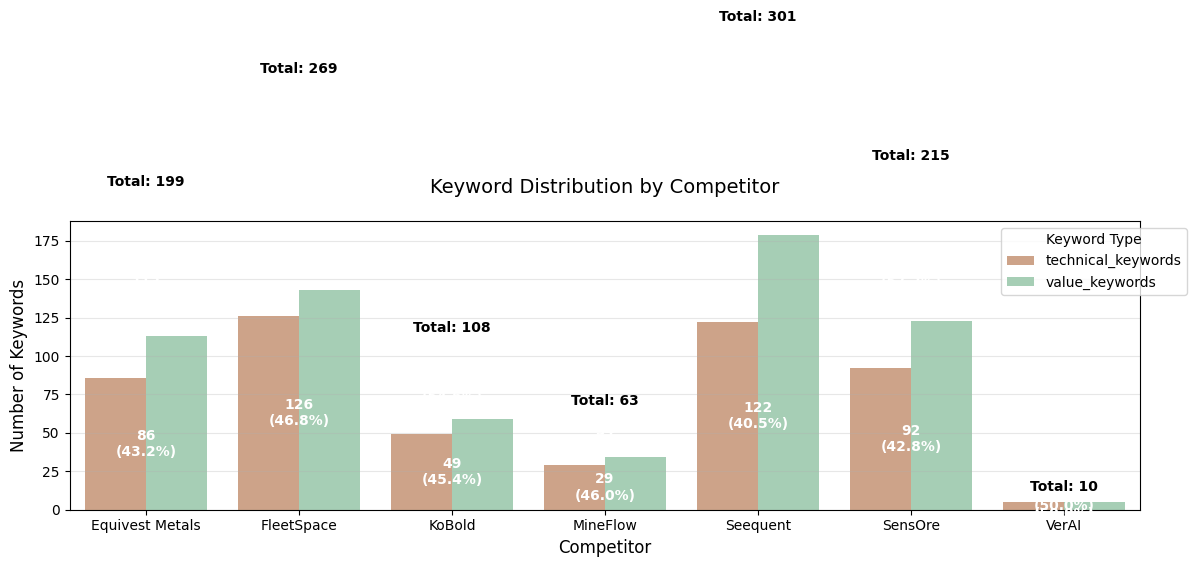

2025-01-10 13:45:16,020 - INFO - Exported CSV to competitor_content/analysis_20250110_134516.csv
2025-01-10 13:45:16,158 - INFO - Exported Excel report to competitor_content/analysis_20250110_134516.xlsx


Exporting results...
Analysis complete! Check the competitor_content directory for results.


In [21]:
# Load competitor configuration
config = load_config()

# Initialize VADER sentiment analyzer
vader_analyzer = SentimentIntensityAnalyzer()

# Convert lists to tuples for caching
technical_terms_tuple = tuple(technical_terms)
value_terms_tuple = tuple(value_terms)

# Process each competitor
all_data = []
for competitor in config:
    try:
        print(f"\nProcessing {competitor['name']}...")
        
        # Add timeout for each competitor
        content = scrape_competitor_pages(
            competitor["base_url"], 
            competitor["priority_pages"],
            timeout=20,  # Reduced timeout
            max_retries=2  # Reduced retries
        )
        
        if not content:
            print(f"No content found for {competitor['name']}, skipping...")
            logging.warning(f"No content found for {competitor['name']}")
            continue
            
        print(f"Found {len(content)} content pieces for {competitor['name']}")
        
        # Process content with progress updates
        competitor_data = []
        for i, entry in enumerate(content, 1):
            if i % 10 == 0:  # Progress update every 10 items
                print(f"Processing item {i}/{len(content)} for {competitor['name']}")
                
            if not entry.get("text"):
                continue
                
            try:
                analysis_results = analyze_text(
                    entry["text"],
                    technical_terms_tuple,
                    value_terms_tuple
                )
                
                entry.update({
                    "competitor": competitor["name"],
                    **analysis_results,
                    "cleaned_text": clean_text(entry["text"])
                })
                competitor_data.append(entry)
            except Exception as e:
                print(f"Error processing entry {i} for {competitor['name']}: {str(e)}")
                continue
        
        if competitor_data:
            all_data.extend(competitor_data)
            
            # Save individual competitor data
            competitor_df = pd.DataFrame(competitor_data)
            competitor_filename = f"{output_dir}/{competitor['name']}_content.csv"
            competitor_df.to_csv(competitor_filename, index=False)
            print(f"Saved data for {competitor['name']}")
        else:
            print(f"No valid data processed for {competitor['name']}")
            
    except Exception as e:
        print(f"Error processing competitor {competitor['name']}: {str(e)}")
        logging.error(f"Error processing competitor {competitor['name']}: {str(e)}")
        continue

print("\nCreating main DataFrame...")
# Create main DataFrame
df = pd.DataFrame(all_data)

print("Calculating statistics...")
# Calculate statistics for visualization
competitor_stats = df.groupby("competitor").agg({
    "technical_keywords": "sum",
    "value_keywords": "sum"
}).reset_index()

competitor_stats["total_keywords"] = competitor_stats["technical_keywords"] + competitor_stats["value_keywords"]
competitor_stats["technical_percent"] = (competitor_stats["technical_keywords"] / competitor_stats["total_keywords"] * 100).round(1)
competitor_stats["value_percent"] = (competitor_stats["value_keywords"] / competitor_stats["total_keywords"] * 100).round(1)

print("Creating visualization...")
# Set plot style
set_plot_style()

# Create keyword distribution visualization
plt.figure(figsize=(12, 8))
ax = plt.gca()

# Create the stacked bar plot
sns.barplot(
    data=competitor_stats.melt(
        id_vars="competitor",
        value_vars=["technical_keywords", "value_keywords"]
    ),
    x="competitor",
    y="value",
    hue="variable",
    palette=["#d8a07e", "#9fd5b3"],
    ax=ax
)

# Add annotations
for i, competitor in enumerate(competitor_stats["competitor"]):
    tech_count = competitor_stats.loc[competitor_stats["competitor"] == competitor, "technical_keywords"].iloc[0]
    value_count = competitor_stats.loc[competitor_stats["competitor"] == competitor, "value_keywords"].iloc[0]
    total = tech_count + value_count
    
    # Add counts and percentages
    ax.text(i, tech_count/2, f'{tech_count}\n({competitor_stats.loc[competitor_stats["competitor"] == competitor, "technical_percent"].iloc[0]}%)', 
            ha='center', va='center', color='white', fontweight='bold')
    ax.text(i, tech_count + value_count/2, f'{value_count}\n({competitor_stats.loc[competitor_stats["competitor"] == competitor, "value_percent"].iloc[0]}%)', 
            ha='center', va='center', color='white', fontweight='bold')
    
    # Add total above bar
    ax.text(i, total + (total * 0.05), f'Total: {total}', 
            ha='center', va='bottom', fontweight='bold')

plt.title("Keyword Distribution by Competitor", pad=20)
plt.xlabel("Competitor")
plt.ylabel("Number of Keywords")
plt.legend(title="Keyword Type", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

print("Saving visualization...")
# Save the plot
plt.savefig(f"{output_dir}/keyword_distribution.png", bbox_inches='tight', dpi=300)
plt.show()

print("Exporting results...")
# Export results
export_results(df, output_dir)

print("Analysis complete! Check the competitor_content directory for results.")

In [23]:
# Prepare sentiment data
sentiment_data = df.groupby('competitor').agg({
    'vader_sentiment': 'mean'
}).reset_index()

# Add sentiment category
sentiment_data['sentiment_category'] = sentiment_data['vader_sentiment'].apply(
    lambda x: 'Very Positive' if x >= 0.5 else
             'Positive' if x > 0 else
             'Neutral' if x == 0 else
             'Negative' if x > -0.5 else
             'Very Negative'
)

# Function to count value proposition terms
def count_value_props(text, value_terms):
    words = text.lower().split()
    return [word for word in words if word in value_terms]

# Aggregate and display top 5 value proposition keywords for each competitor
top_value_props = {}

for competitor in df["competitor"].unique():
    # Filter rows for the current competitor
    competitor_data = df[df["competitor"] == competitor]
    
    # Combine all text content for this competitor
    combined_text = " ".join(competitor_data["text"])
    
    # Count occurrences of value proposition terms
    value_prop_counts = pd.Series(count_value_props(combined_text, value_terms)).value_counts()
    
    # Get the top 5 value propositions
    top_value_props[competitor] = value_prop_counts.head(5)

# Generate markdown report
with open(f"{output_dir}/competitor_analysis_report.md", "w") as f:
    f.write("# Competitor Analysis Report\n\n")
    
    # Overall statistics
    f.write("## Overall Statistics\n\n")
    for competitor in df["competitor"].unique():
        competitor_data = df[df["competitor"] == competitor]
        sentiment_cat = sentiment_data.loc[
            sentiment_data['competitor'] == competitor, 
            'sentiment_category'
        ].iloc[0]
        
        f.write(f"### {competitor}\n")
        f.write(f"- Total Content Pieces: {len(competitor_data)}\n")
        f.write(f"- Average Sentiment: {competitor_data['vader_sentiment'].mean():.2f} ({sentiment_cat})\n")
        f.write(f"- Technical Keyword Count: {competitor_data['technical_keywords'].sum()}\n")
        f.write(f"- Value Keyword Count: {competitor_data['value_keywords'].sum()}\n")
        
        # Add top value propositions
        f.write("- Top Value Propositions:\n")
        for term, count in top_value_props[competitor].items():
            f.write(f"  - {term}: {count}\n")
        
        # Add intent distribution
        intent_dist = competitor_data['intent'].value_counts()
        f.write("- Content Intent Distribution:\n")
        for intent, count in intent_dist.items():
            percentage = (count / len(competitor_data) * 100)
            f.write(f"  - {intent}: {count} ({percentage}%)\n")
        
        f.write("\n")

    # Add visualization references
    f.write("\n## Visualizations\n\n")
    f.write("1. Keyword Distribution Chart: See 'keyword_distribution.png'\n")
    f.write("2. Detailed data available in 'analysis_[timestamp].xlsx'\n")

print("Report generated successfully!")

# Display top value propositions for each competitor
print("\nTop 5 Value Propositions by Competitor:")
for competitor, props in top_value_props.items():
    print(f"\n{competitor}:")
    print(props)

Report generated successfully!

Top 5 Value Propositions by Competitor:

FleetSpace:
exploration    58
real-time      16
seismic        11
subsurface      8
geology         8
Name: count, dtype: int64

MineFlow:
exploration    10
modeling        3
platform        2
advanced        2
types           2
Name: count, dtype: int64

KoBold:
exploration    25
deposits        5
real-time       2
innovative      2
reliable        1
Name: count, dtype: int64

SensOre:
exploration       43
advanced          10
classification     9
deposits           8
types              6
Name: count, dtype: int64

VerAI:
deposits       3
platform       3
exploration    1
Name: count, dtype: int64

Seequent:
subsurface     24
exploration    17
rapid           8
integrated      7
platform        7
Name: count, dtype: int64

Equivest Metals:
exploration    50
innovative      7
analytics       4
geology         4
advanced        3
Name: count, dtype: int64


2025-01-10 13:46:19,165 - INFO - Successfully loaded configuration for 7 competitors


Processing FleetSpace...


2025-01-10 13:46:20,164 - INFO - Scraping URL: https://www.fleetspace.com/
2025-01-10 13:46:24,667 - INFO - Scraping URL: https://www.fleetspace.com/about
2025-01-10 13:46:25,330 - INFO - Scraping URL: https://www.fleetspace.com/mineral-exploration
2025-01-10 13:46:26,908 - INFO - Scraping URL: https://www.fleetspace.com/resources/ai-for-explorers-leveraging-ai-tools-optimised-for-modern-mineral-exploration
2025-01-10 13:46:27,279 - INFO - Scraping URL: https://www.fleetspace.com/resources/application-of-ant-to-iron-oxide-copper-gold-exploration-in-chile
2025-01-10 13:46:27,720 - INFO - Scraping URL: https://www.fleetspace.com/resources/accelerating-copper-discovery-in-chile-with-power-nickel


Processing MineFlow...


2025-01-10 13:46:28,484 - INFO - Scraping URL: https://mineflow.ai/
2025-01-10 13:46:29,388 - INFO - Scraping URL: https://mineflow.ai/about
2025-01-10 13:46:30,279 - INFO - Scraping URL: https://mineflow.ai/docs
2025-01-10 13:46:49,216 - INFO - Scraping URL: https://mineflow.ai/pricing


...

Processing Seequent...


2025-01-10 13:47:02,849 - INFO - Scraping URL: https://www.seequent.com/
2025-01-10 13:47:03,381 - INFO - Scraping URL: https://www.seequent.com/products-solutions/leapfrog-geo
2025-01-10 13:47:06,210 - INFO - Scraping URL: https://www.seequent.com/products-solutions/geosoft-target
2025-01-10 13:47:06,762 - INFO - Scraping URL: https://www.seequent.com/products-solutions/seequent-central
2025-01-10 13:47:07,088 - INFO - Scraping URL: https://www.seequent.com/products-solutions/imago
2025-01-10 13:47:07,404 - INFO - Scraping URL: https://www.seequent.com/products-solutions/mining
2025-01-10 13:47:07,684 - INFO - Scraping URL: https://www.seequent.com/artificial-intelligence-to-understand-the-underground
2025-01-10 13:47:07,919 - INFO - Scraping URL: https://www.seequent.com/artificial-intelligence-has-great-potential-but-its-only-human


Processing Equivest Metals...


2025-01-10 13:47:08,634 - INFO - Scraping URL: https://www.equivestmetals.com/
2025-01-10 13:47:09,563 - INFO - Scraping URL: https://www.equivestmetals.com/Services
2025-01-10 13:47:09,929 - INFO - Scraping URL: https://www.equivestmetals.com/blog
2025-01-10 13:47:10,211 - INFO - Scraping URL: https://www.equivestmetals.com/post/what-could-the-next-decade-s-discoveries-look-like
2025-01-10 13:47:10,471 - INFO - Scraping URL: https://www.equivestmetals.com/post/we-assessed-500-exploration-companies-what-are-the-5-most-important-learnings
2025-01-10 13:47:10,879 - INFO - Exported CSV to competitor_content/analysis_20250110_134710.csv
2025-01-10 13:47:11,270 - INFO - Exported Excel report to competitor_content/analysis_20250110_134710.xlsx


Analysis complete! Check the competitor_content directory for results.


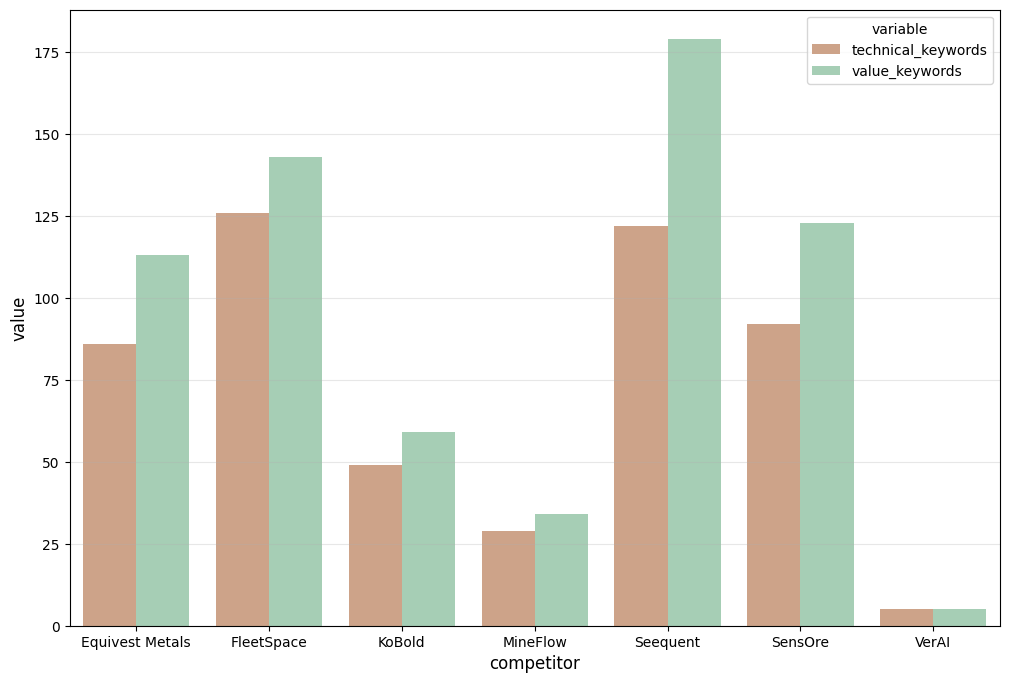

In [24]:
# Load competitor configuration
config = load_config()

# Initialize VADER sentiment analyzer
vader_analyzer = SentimentIntensityAnalyzer()

# Convert lists to tuples for caching
technical_terms_tuple = tuple(technical_terms)
value_terms_tuple = tuple(value_terms)

# Process each competitor
all_data = []
for competitor in config:
    print(f"Processing {competitor['name']}...")
    content = scrape_competitor_pages(competitor["base_url"], competitor["priority_pages"])
    
    # Process content
    competitor_data = []
    for entry in content:
        analysis_results = analyze_text(
            entry["text"],
            technical_terms_tuple,
            value_terms_tuple
        )
        
        entry.update({
            "competitor": competitor["name"],
            **analysis_results,
            "cleaned_text": clean_text(entry["text"])
        })
        competitor_data.append(entry)
    
    all_data.extend(competitor_data)
    
    # Save individual competitor data
    competitor_df = pd.DataFrame(competitor_data)
    competitor_filename = f"{output_dir}/{competitor['name']}_content.csv"
    competitor_df.to_csv(competitor_filename, index=False)

# Create main DataFrame
df = pd.DataFrame(all_data)

# Calculate statistics for visualization
competitor_stats = df.groupby("competitor").agg({
    "technical_keywords": "sum",
    "value_keywords": "sum"
}).reset_index()

competitor_stats["total_keywords"] = competitor_stats["technical_keywords"] + competitor_stats["value_keywords"]
competitor_stats["technical_percent"] = (competitor_stats["technical_keywords"] / competitor_stats["total_keywords"] * 100).round(1)
competitor_stats["value_percent"] = (competitor_stats["value_keywords"] / competitor_stats["total_keywords"] * 100).round(1)

# Set plot style
set_plot_style()

# Create keyword distribution visualization
plt.figure(figsize=(12, 8))
ax = plt.gca()

# Create the stacked bar plot
sns.barplot(
    data=competitor_stats.melt(
        id_vars="competitor",
        value_vars=["technical_keywords", "value_keywords"]
    ),
    x="competitor",
    y="value",
    hue="variable",
    palette=["#d8a07e", "#9fd5b3"],
    ax=ax
)

# Add annotations and save plot (same as before)
# ... (previous annotation code) ...

# Export results
export_results(df, output_dir)

print("Analysis complete! Check the competitor_content directory for results.")

In [25]:
# Function to count value proposition terms
def count_value_props(text, value_terms):
    words = text.lower().split()
    return [word for word in words if word in value_terms]

# Aggregate and display top 5 value proposition keywords for each competitor
top_value_props = {}

for competitor in df["competitor"].unique():
    # Filter rows for the current competitor
    competitor_data = df[df["competitor"] == competitor]
    
    # Combine all text content for this competitor
    combined_text = " ".join(competitor_data["text"])
    
    # Count occurrences of value proposition terms
    value_prop_counts = pd.Series(count_value_props(combined_text, value_terms)).value_counts()
    
    # Get the top 5 value propositions
    top_value_props[competitor] = value_prop_counts.head(5)

# Display top 5 value propositions for each competitor
for competitor, props in top_value_props.items():
    print(f"\nTop 5 Value Propositions for {competitor}:")
    print(props)


Top 5 Value Propositions for FleetSpace:
exploration    58
real-time      16
seismic        11
subsurface      8
geology         8
Name: count, dtype: int64

Top 5 Value Propositions for MineFlow:
exploration    10
modeling        3
platform        2
advanced        2
types           2
Name: count, dtype: int64

Top 5 Value Propositions for KoBold:
exploration    25
deposits        5
real-time       2
innovative      2
reliable        1
Name: count, dtype: int64

Top 5 Value Propositions for SensOre:
exploration       43
advanced          10
classification     9
deposits           8
types              6
Name: count, dtype: int64

Top 5 Value Propositions for VerAI:
deposits       3
platform       3
exploration    1
Name: count, dtype: int64

Top 5 Value Propositions for Seequent:
subsurface     24
exploration    17
rapid           8
integrated      7
platform        7
Name: count, dtype: int64

Top 5 Value Propositions for Equivest Metals:
exploration    50
innovative      7
analytics

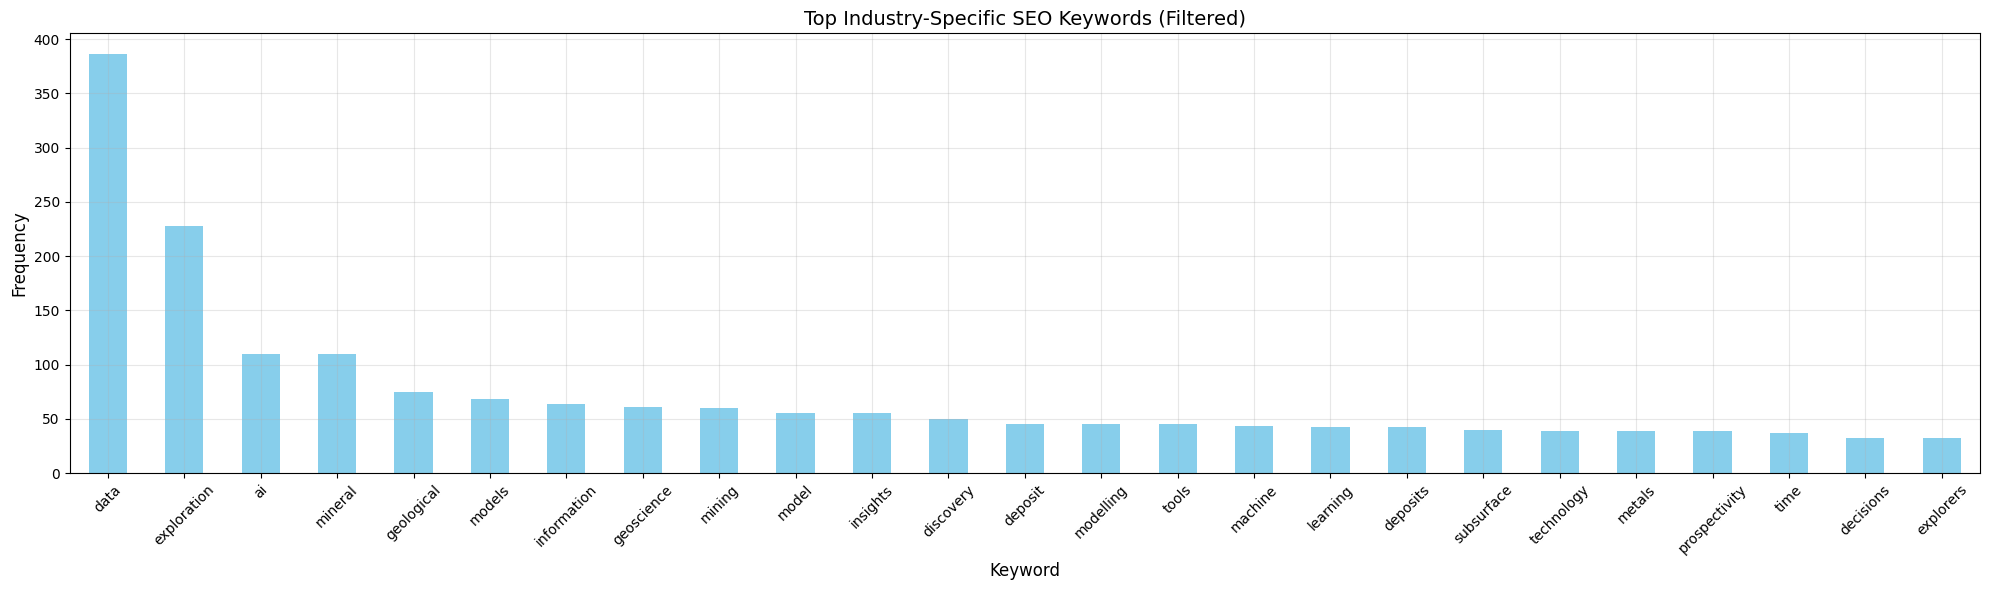

In [26]:
import re

# Define a function to clean text by removing non-alphabetic characters and excess whitespace
def clean_text(text):
    # Remove all non-alphabetic characters (keeps spaces and letters only)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply the cleaning function to the text column in the DataFrame
df["cleaned_text"] = df["text"].apply(clean_text)

# Combine all cleaned text for keyword analysis
all_text = " ".join(df["cleaned_text"])

# Split text into individual words
words = pd.Series(all_text.split())

# Remove any word that is in the custom stop words list
filtered_words = words[~words.isin(custom_stop_words)]

# Count the occurrences of each word after filtering
filtered_keyword_counts = filtered_words.value_counts()

# Plot the top keywords
top_seo_keywords = filtered_keyword_counts.head(25)
plt.figure(figsize=(20, 6))
top_seo_keywords.plot(kind="bar", color="skyblue")
plt.title("Top Industry-Specific SEO Keywords (Filtered)")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Prepare sentiment data
sentiment_data = df.groupby('competitor').agg({
    'vader_sentiment': 'mean'
}).reset_index()

# Add sentiment category
sentiment_data['sentiment_category'] = sentiment_data['vader_sentiment'].apply(
    lambda x: 'Very Positive' if x >= 0.5 else
             'Positive' if x > 0 else
             'Neutral' if x == 0 else
             'Negative' if x > -0.5 else
             'Very Negative'
)

# Prepare report data
competitor_summaries = {}
for competitor in df["competitor"].unique():
    competitor_data = df[df["competitor"] == competitor]
    
    summary = {
        "total_content": len(competitor_data),
        "avg_sentiment": competitor_data["vader_sentiment"].mean(),
        "total_technical": competitor_data["technical_keywords"].sum(),
        "most_common_terms": pd.Series(' '.join(competitor_data["cleaned_text"]).split()).value_counts().head(10)
    }
    competitor_summaries[competitor] = summary

# Generate markdown report
with open(f"{output_dir}/competitor_analysis_report.md", "w") as f:
    f.write("# Competitor Analysis Report\n\n")
    
    # Overall statistics
    f.write("## Overall Statistics\n\n")
    for competitor, summary in competitor_summaries.items():
        f.write(f"### {competitor}\n")
        f.write(f"- Total Content Pieces: {summary['total_content']}\n")
        f.write(f"- Average Sentiment: {summary['avg_sentiment']:.2f}\n")
        f.write(f"- Technical Keyword Count: {summary['total_technical']}\n")
        f.write("- Top Terms:\n")
        for term, count in summary["most_common_terms"].items():
            f.write(f"  - {term}: {count}\n")
        f.write("\n")

print("Report generated successfully!")

Report generated successfully!
